PRUEBA CON DATOS 20HZ, WINDOW 121, DENSE 16, DROP 0.4

Archivos localizados: 48
Secuencias extraídas tras filtros físicos: (48, 121, 6)

Iniciando Evaluación Híbrida con Datos Reales...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 67.41 m | R2: 0.9252

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 131.08 m | R2: 0.8176

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 81.14 m | R2: 0.9248

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 46.83 m | R2: 0.9824

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 64.48 m | R2: 0.9398

RESUMEN LSTM Híbrida — ARCHIVOS ORIGINALES (METROS REALES)
MAE  : 78.19 ± 28.62 metros
RMSE : 121.87 metros
R2   : 0.9180


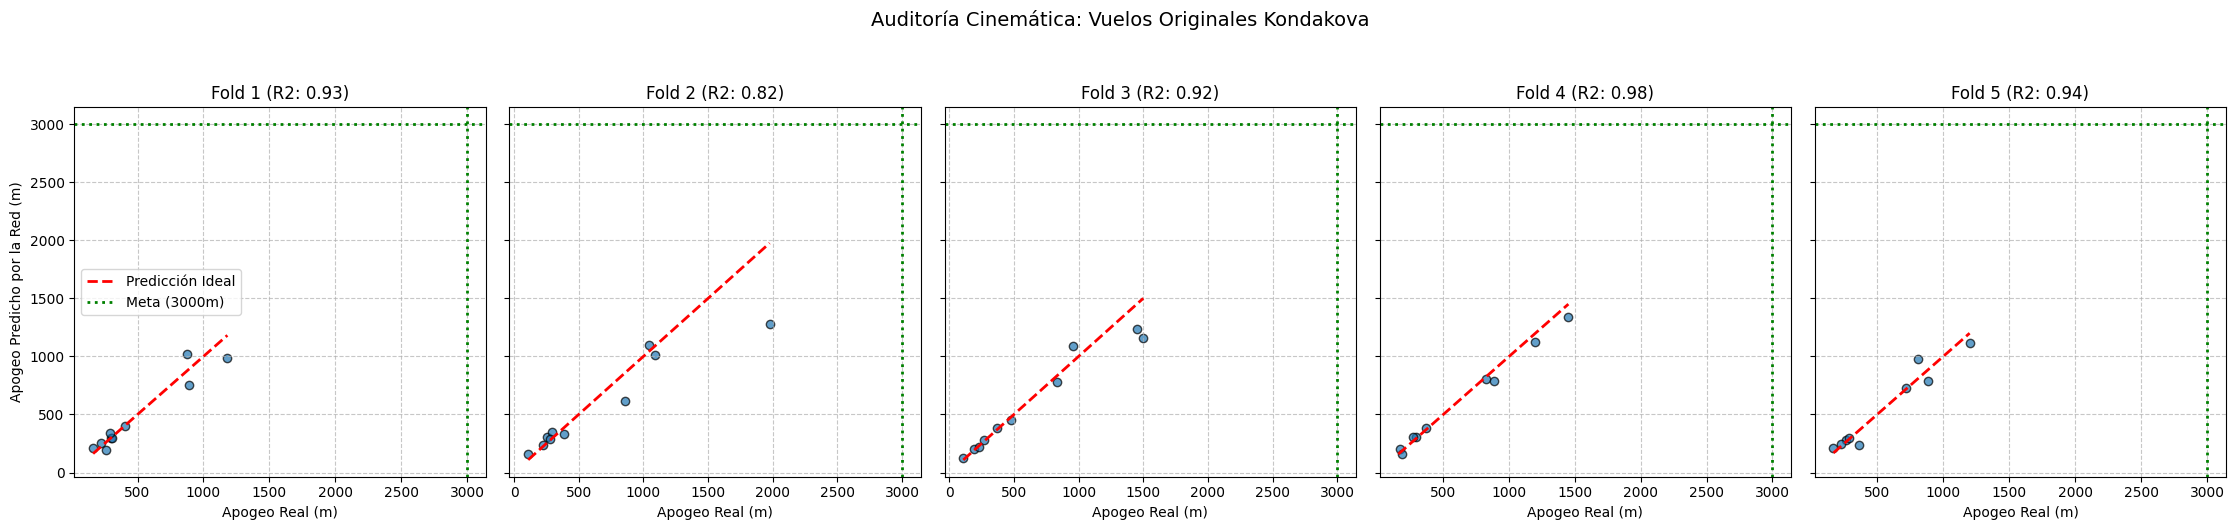

In [49]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS ORIGINALES (CON RECONSTRUCCIÓN FÍSICA Y TRIGGER GLOBAL)
# ==============================================================================
# Ajusta esta ruta a tu carpeta con los 48 archivos CSV originales
PROCESSED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/20Hz")
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_originales)}")

# Ventana de 10 segundos (201 muestras a 20Hz) para capturar el MECO
WINDOW_SIZE = 121 
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_originales:
    # 1.1 Leer archivo y limpiar espacios invisibles en los encabezados
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.strip()
    df = df.sort_values("time").reset_index(drop=True)
    
    # 1.2 Reconstruir las características que la IMU no guardó directamente
    if 'At' not in df.columns:
        # Aceleración Total (Magnitud del vector 3D)
        df['At'] = np.sqrt(df['accl_x']**2 + df['accl_y']**2 + df['accl_z']**2)
        
    if 'P' not in df.columns:
        # Reconstruir Presión Atmosférica (Pa) a partir de la Altitud (m) 
        # usando el modelo de Atmósfera Estándar Internacional (ISA)
        df['P'] = 101325.0 * (1 - 2.25577e-5 * df['baro_altitude'])**5.25588
            
    apogeo_real = df["baro_altitude"].max()
    
    # Filtro de sobre de vuelo (Ignoramos vuelos erráticos de más de 4500m)
    if apogeo_real > 4500:
        continue
    
    # 1.3 DISPARADOR DE DESPEGUE ROBUSTO
    # Usamos At > 15 m/s^2 (aprox 1.5G). Al usar At, no importa cómo orientaron la placa.
    despegues = df[df['At'] > 15].index
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # 1.4 Extraer la ventana exactamente desde el instante del despegue
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.stem) 

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtros físicos: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Usando splits por secuencia en lugar de por vuelo.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN (RobustScaler)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1: axes = [axes]
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        ax.scatter(y_true, y_pred, alpha=0.7, c='#1f77b4', edgecolors='k')
        
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
            ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
            
    plt.suptitle("Auditoría Cinemática: Vuelos Originales Kondakova", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida_Originales")
    model.add(Input(shape=input_shape))
    
    # Reducimos GaussianNoise porque la IMU real ya tiene suficiente vibración
    model.add(GaussianNoise(0.01)) 
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    
    model.add(BatchNormalization())
    model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.4))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    
    return model

# ==============================================================================
# 5. EJECUCIÓN
# ==============================================================================
print("\nIniciando Evaluación Híbrida con Datos Reales...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=200, 
    batch_size=16, 
    patience=30
)

summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — ARCHIVOS ORIGINALES")
plot_kfold_diagnostics(cv_lstm_v5_folds)

PRUEBA CON DATOS 20HZ, WINDOW 121, DENSE 32, DROP 0.4

Archivos localizados: 48
Secuencias extraídas tras filtros físicos: (48, 121, 6)

Iniciando Evaluación Híbrida con Datos Reales...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 53.28 m | R2: 0.9311

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 216.23 m | R2: 0.5207

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 154.87 m | R2: 0.6462

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 82.82 m | R2: 0.9220

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 62.21 m | R2: 0.9534

RESUMEN LSTM Híbrida — ARCHIVOS ORIGINALES (METROS REALES)
MAE  : 113.88 ± 62.39 metros
RMSE : 193.41 metros
R2   : 0.7947


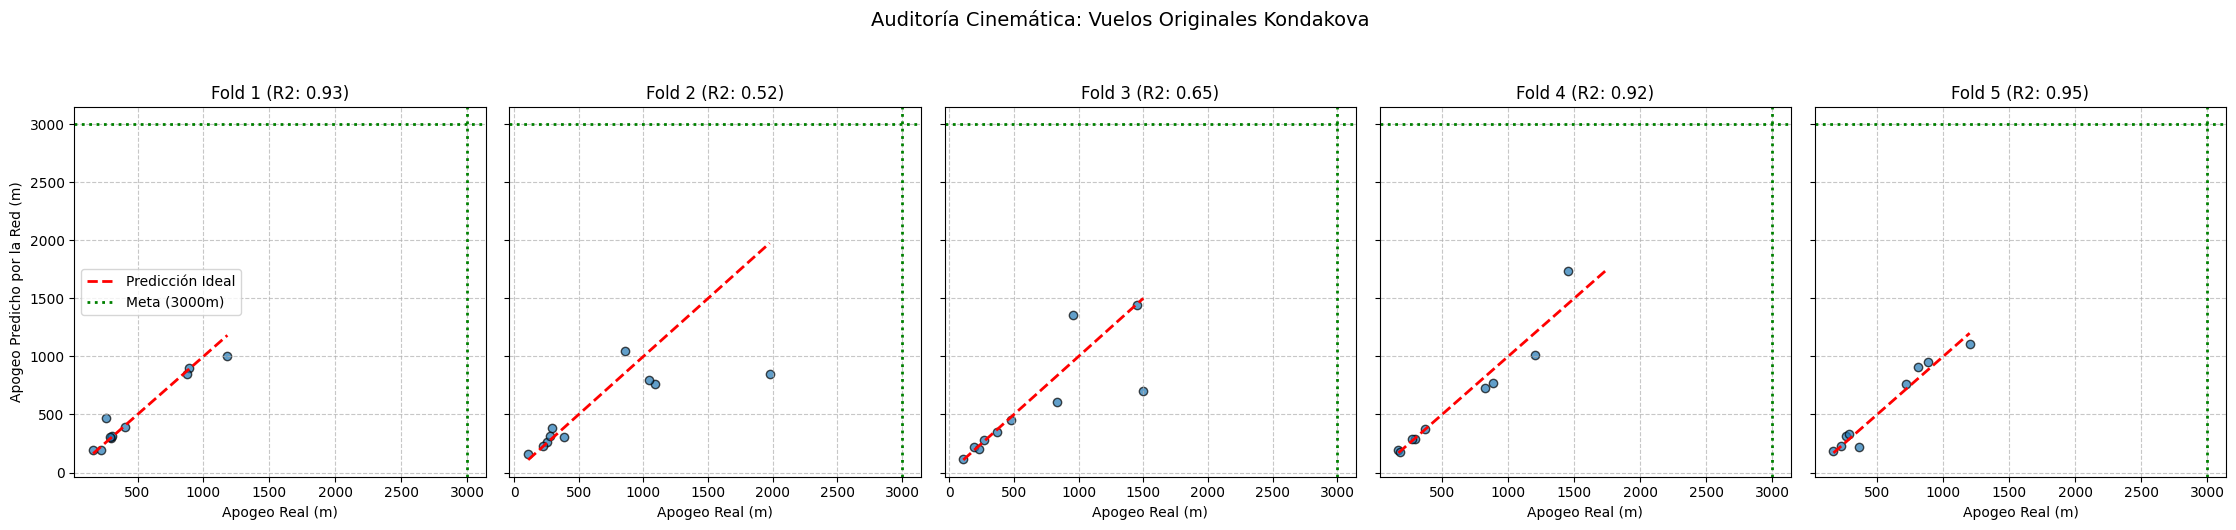

In [50]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS ORIGINALES (CON RECONSTRUCCIÓN FÍSICA Y TRIGGER GLOBAL)
# ==============================================================================
# Ajusta esta ruta a tu carpeta con los 48 archivos CSV originales
PROCESSED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/20Hz")
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_originales)}")

# Ventana de 10 segundos (201 muestras a 20Hz) para capturar el MECO
WINDOW_SIZE = 121 
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_originales:
    # 1.1 Leer archivo y limpiar espacios invisibles en los encabezados
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.strip()
    df = df.sort_values("time").reset_index(drop=True)
    
    # 1.2 Reconstruir las características que la IMU no guardó directamente
    if 'At' not in df.columns:
        # Aceleración Total (Magnitud del vector 3D)
        df['At'] = np.sqrt(df['accl_x']**2 + df['accl_y']**2 + df['accl_z']**2)
        
    if 'P' not in df.columns:
        # Reconstruir Presión Atmosférica (Pa) a partir de la Altitud (m) 
        # usando el modelo de Atmósfera Estándar Internacional (ISA)
        df['P'] = 101325.0 * (1 - 2.25577e-5 * df['baro_altitude'])**5.25588
            
    apogeo_real = df["baro_altitude"].max()
    
    # Filtro de sobre de vuelo (Ignoramos vuelos erráticos de más de 4500m)
    if apogeo_real > 4500:
        continue
    
    # 1.3 DISPARADOR DE DESPEGUE ROBUSTO
    # Usamos At > 15 m/s^2 (aprox 1.5G). Al usar At, no importa cómo orientaron la placa.
    despegues = df[df['At'] > 15].index
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # 1.4 Extraer la ventana exactamente desde el instante del despegue
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.stem) 

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtros físicos: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Usando splits por secuencia en lugar de por vuelo.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN (RobustScaler)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1: axes = [axes]
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        ax.scatter(y_true, y_pred, alpha=0.7, c='#1f77b4', edgecolors='k')
        
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
            ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
            
    plt.suptitle("Auditoría Cinemática: Vuelos Originales Kondakova", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida_Originales")
    model.add(Input(shape=input_shape))
    
    # Reducimos GaussianNoise porque la IMU real ya tiene suficiente vibración
    model.add(GaussianNoise(0.01)) 
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    
    model.add(BatchNormalization())
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.4))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    
    return model

# ==============================================================================
# 5. EJECUCIÓN
# ==============================================================================
print("\nIniciando Evaluación Híbrida con Datos Reales...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=200, 
    batch_size=16, 
    patience=30
)

summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — ARCHIVOS ORIGINALES")
plot_kfold_diagnostics(cv_lstm_v5_folds)

PRUEBA CON DATOS 20HZ, WINDOW 121, DENSE 64, DROP 0.4

Archivos localizados: 48
Secuencias extraídas tras filtros físicos: (48, 121, 6)

Iniciando Evaluación Híbrida con Datos Reales...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 61.86 m | R2: 0.9453

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 166.60 m | R2: 0.6940

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 92.72 m | R2: 0.9157

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 55.83 m | R2: 0.9696

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 53.79 m | R2: 0.9566

RESUMEN LSTM Híbrida — ARCHIVOS ORIGINALES (METROS REALES)
MAE  : 86.16 ± 42.60 metros
RMSE : 136.05 metros
R2   : 0.8963


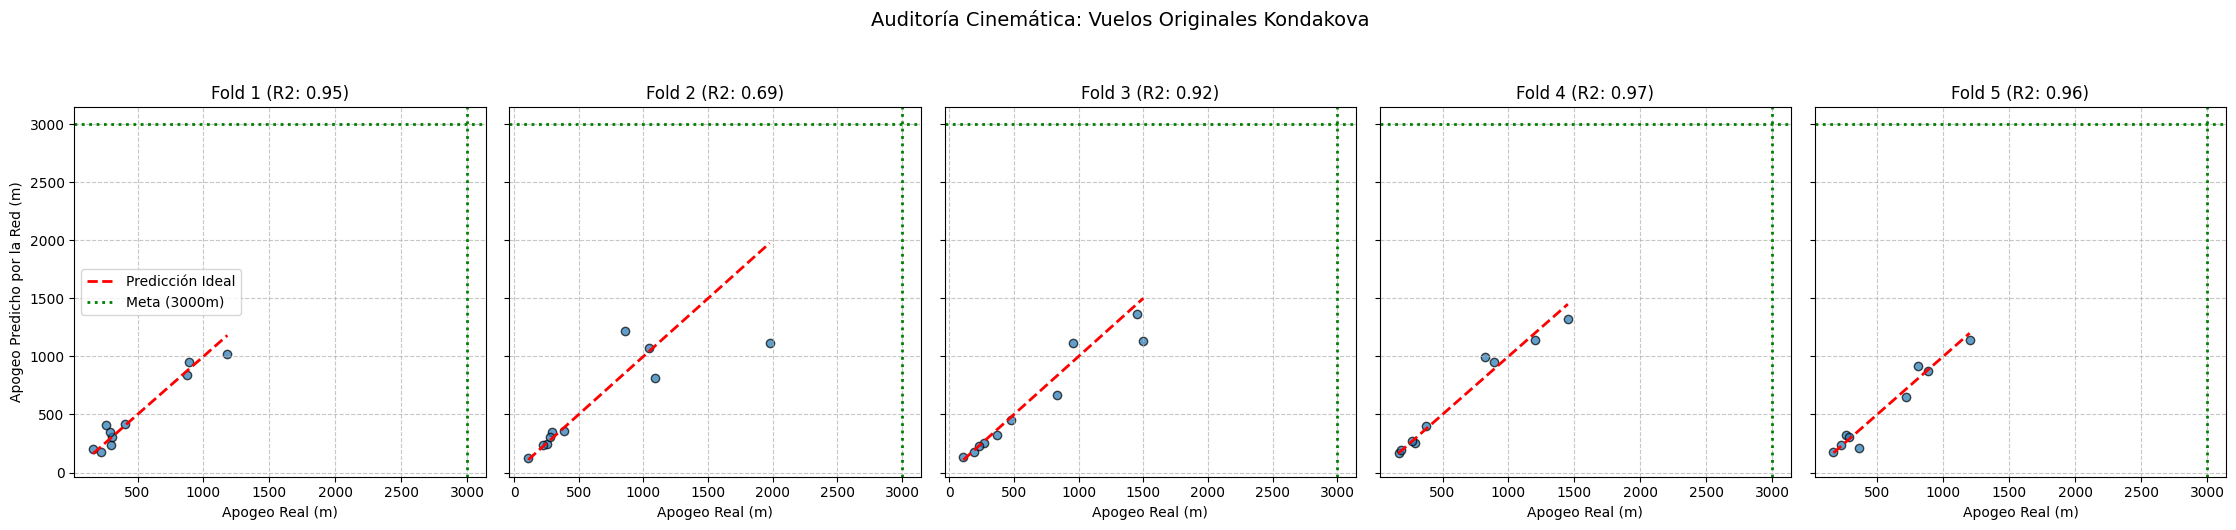

In [51]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS ORIGINALES (CON RECONSTRUCCIÓN FÍSICA Y TRIGGER GLOBAL)
# ==============================================================================
# Ajusta esta ruta a tu carpeta con los 48 archivos CSV originales
PROCESSED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/20Hz")
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_originales)}")

# Ventana de 10 segundos (201 muestras a 20Hz) para capturar el MECO
WINDOW_SIZE = 121 
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_originales:
    # 1.1 Leer archivo y limpiar espacios invisibles en los encabezados
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.strip()
    df = df.sort_values("time").reset_index(drop=True)
    
    # 1.2 Reconstruir las características que la IMU no guardó directamente
    if 'At' not in df.columns:
        # Aceleración Total (Magnitud del vector 3D)
        df['At'] = np.sqrt(df['accl_x']**2 + df['accl_y']**2 + df['accl_z']**2)
        
    if 'P' not in df.columns:
        # Reconstruir Presión Atmosférica (Pa) a partir de la Altitud (m) 
        # usando el modelo de Atmósfera Estándar Internacional (ISA)
        df['P'] = 101325.0 * (1 - 2.25577e-5 * df['baro_altitude'])**5.25588
            
    apogeo_real = df["baro_altitude"].max()
    
    # Filtro de sobre de vuelo (Ignoramos vuelos erráticos de más de 4500m)
    if apogeo_real > 4500:
        continue
    
    # 1.3 DISPARADOR DE DESPEGUE ROBUSTO
    # Usamos At > 15 m/s^2 (aprox 1.5G). Al usar At, no importa cómo orientaron la placa.
    despegues = df[df['At'] > 15].index
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # 1.4 Extraer la ventana exactamente desde el instante del despegue
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.stem) 

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtros físicos: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Usando splits por secuencia en lugar de por vuelo.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN (RobustScaler)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1: axes = [axes]
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        ax.scatter(y_true, y_pred, alpha=0.7, c='#1f77b4', edgecolors='k')
        
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
            ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
            
    plt.suptitle("Auditoría Cinemática: Vuelos Originales Kondakova", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida_Originales")
    model.add(Input(shape=input_shape))
    
    # Reducimos GaussianNoise porque la IMU real ya tiene suficiente vibración
    model.add(GaussianNoise(0.01)) 
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.4))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    
    return model

# ==============================================================================
# 5. EJECUCIÓN
# ==============================================================================
print("\nIniciando Evaluación Híbrida con Datos Reales...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=200, 
    batch_size=16, 
    patience=30
)

summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — ARCHIVOS ORIGINALES")
plot_kfold_diagnostics(cv_lstm_v5_folds)

PRUEBA CON DATOS 20HZ, WINDOW 121, DENSE 16, DROP 0.2

Archivos localizados: 48
Secuencias extraídas tras filtros físicos: (48, 121, 6)

Iniciando Evaluación Híbrida con Datos Reales...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 72.77 m | R2: 0.9170

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 176.97 m | R2: 0.6745

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 108.67 m | R2: 0.8683

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 42.63 m | R2: 0.9812

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 55.39 m | R2: 0.9538

RESUMEN LSTM Híbrida — ARCHIVOS ORIGINALES (METROS REALES)
MAE  : 91.29 ± 48.25 metros
RMSE : 145.90 metros
R2   : 0.8789


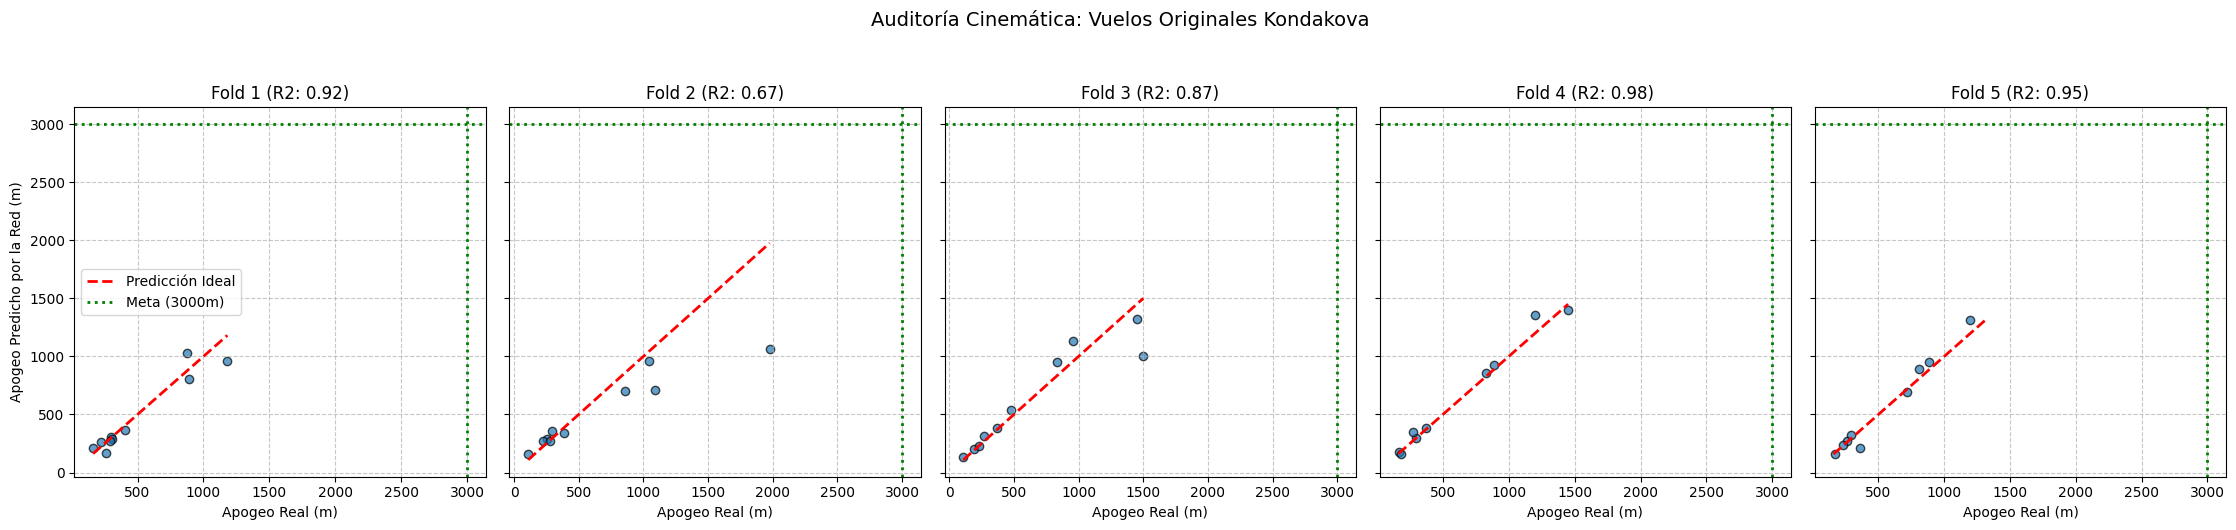

In [52]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS ORIGINALES (CON RECONSTRUCCIÓN FÍSICA Y TRIGGER GLOBAL)
# ==============================================================================
# Ajusta esta ruta a tu carpeta con los 48 archivos CSV originales
PROCESSED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/20Hz")
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_originales)}")

# Ventana de 10 segundos (201 muestras a 20Hz) para capturar el MECO
WINDOW_SIZE = 121 
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_originales:
    # 1.1 Leer archivo y limpiar espacios invisibles en los encabezados
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.strip()
    df = df.sort_values("time").reset_index(drop=True)
    
    # 1.2 Reconstruir las características que la IMU no guardó directamente
    if 'At' not in df.columns:
        # Aceleración Total (Magnitud del vector 3D)
        df['At'] = np.sqrt(df['accl_x']**2 + df['accl_y']**2 + df['accl_z']**2)
        
    if 'P' not in df.columns:
        # Reconstruir Presión Atmosférica (Pa) a partir de la Altitud (m) 
        # usando el modelo de Atmósfera Estándar Internacional (ISA)
        df['P'] = 101325.0 * (1 - 2.25577e-5 * df['baro_altitude'])**5.25588
            
    apogeo_real = df["baro_altitude"].max()
    
    # Filtro de sobre de vuelo (Ignoramos vuelos erráticos de más de 4500m)
    if apogeo_real > 4500:
        continue
    
    # 1.3 DISPARADOR DE DESPEGUE ROBUSTO
    # Usamos At > 15 m/s^2 (aprox 1.5G). Al usar At, no importa cómo orientaron la placa.
    despegues = df[df['At'] > 15].index
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # 1.4 Extraer la ventana exactamente desde el instante del despegue
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.stem) 

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtros físicos: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Usando splits por secuencia en lugar de por vuelo.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN (RobustScaler)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1: axes = [axes]
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        ax.scatter(y_true, y_pred, alpha=0.7, c='#1f77b4', edgecolors='k')
        
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
            ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
            
    plt.suptitle("Auditoría Cinemática: Vuelos Originales Kondakova", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida_Originales")
    model.add(Input(shape=input_shape))
    
    # Reducimos GaussianNoise porque la IMU real ya tiene suficiente vibración
    model.add(GaussianNoise(0.01)) 
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    
    model.add(BatchNormalization())
    model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    
    return model

# ==============================================================================
# 5. EJECUCIÓN
# ==============================================================================
print("\nIniciando Evaluación Híbrida con Datos Reales...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=200, 
    batch_size=16, 
    patience=30
)

summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — ARCHIVOS ORIGINALES")
plot_kfold_diagnostics(cv_lstm_v5_folds)

PRUEBA CON DATOS 20 HZ, WINDOW 121, DENSE 32, DROP 0.2

Archivos localizados: 48
Secuencias extraídas tras filtros físicos: (48, 121, 6)

Iniciando Evaluación Híbrida con Datos Reales...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 54.85 m | R2: 0.9497

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 167.89 m | R2: 0.7415

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 102.10 m | R2: 0.8652

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 52.69 m | R2: 0.9702

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 54.71 m | R2: 0.9599

RESUMEN LSTM Híbrida — ARCHIVOS ORIGINALES (METROS REALES)
MAE  : 86.45 ± 44.77 metros
RMSE : 137.27 metros
R2   : 0.8973


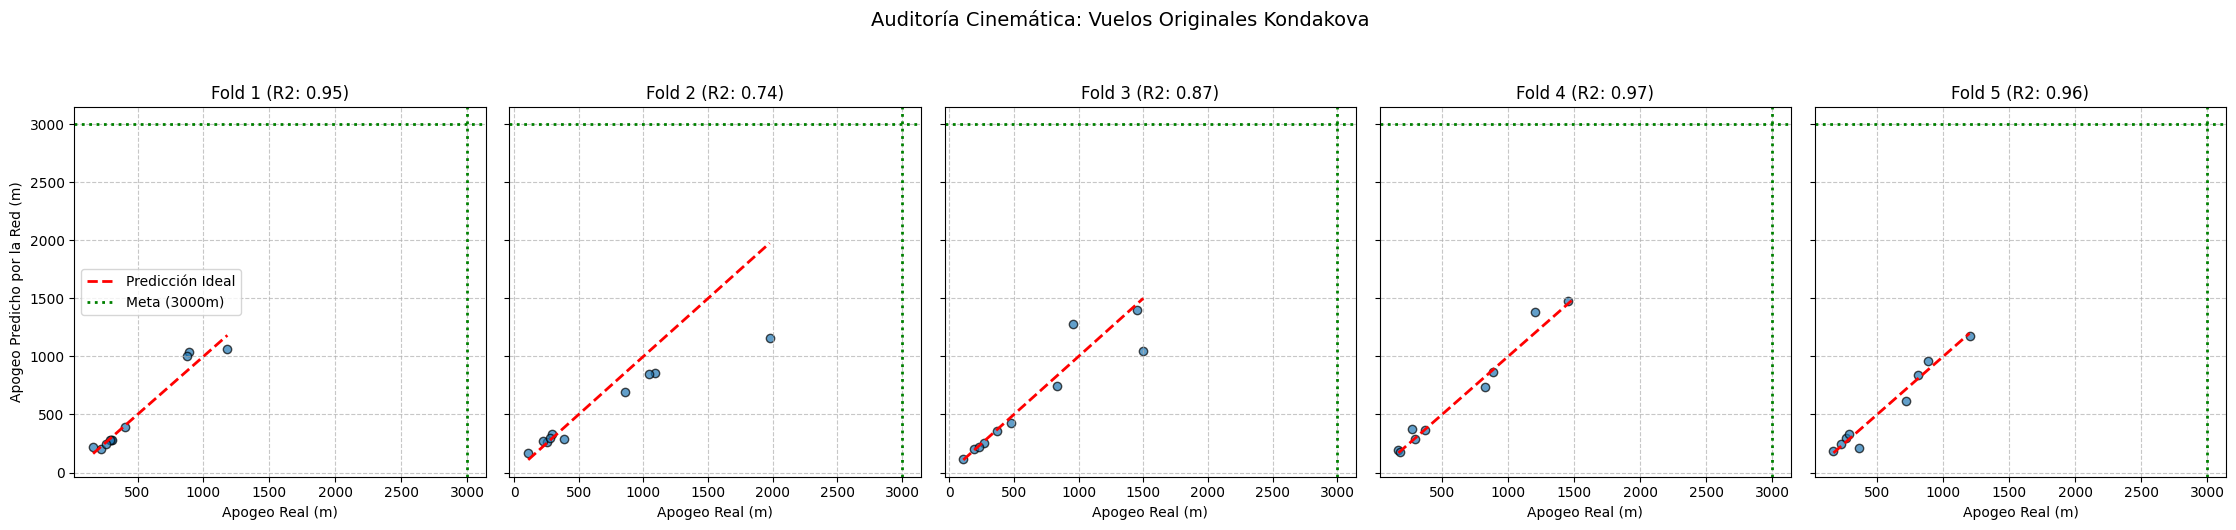

In [53]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS ORIGINALES (CON RECONSTRUCCIÓN FÍSICA Y TRIGGER GLOBAL)
# ==============================================================================
# Ajusta esta ruta a tu carpeta con los 48 archivos CSV originales
PROCESSED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/20Hz")
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_originales)}")

# Ventana de 10 segundos (201 muestras a 20Hz) para capturar el MECO
WINDOW_SIZE = 121 
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_originales:
    # 1.1 Leer archivo y limpiar espacios invisibles en los encabezados
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.strip()
    df = df.sort_values("time").reset_index(drop=True)
    
    # 1.2 Reconstruir las características que la IMU no guardó directamente
    if 'At' not in df.columns:
        # Aceleración Total (Magnitud del vector 3D)
        df['At'] = np.sqrt(df['accl_x']**2 + df['accl_y']**2 + df['accl_z']**2)
        
    if 'P' not in df.columns:
        # Reconstruir Presión Atmosférica (Pa) a partir de la Altitud (m) 
        # usando el modelo de Atmósfera Estándar Internacional (ISA)
        df['P'] = 101325.0 * (1 - 2.25577e-5 * df['baro_altitude'])**5.25588
            
    apogeo_real = df["baro_altitude"].max()
    
    # Filtro de sobre de vuelo (Ignoramos vuelos erráticos de más de 4500m)
    if apogeo_real > 4500:
        continue
    
    # 1.3 DISPARADOR DE DESPEGUE ROBUSTO
    # Usamos At > 15 m/s^2 (aprox 1.5G). Al usar At, no importa cómo orientaron la placa.
    despegues = df[df['At'] > 15].index
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # 1.4 Extraer la ventana exactamente desde el instante del despegue
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.stem) 

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtros físicos: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Usando splits por secuencia en lugar de por vuelo.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN (RobustScaler)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1: axes = [axes]
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        ax.scatter(y_true, y_pred, alpha=0.7, c='#1f77b4', edgecolors='k')
        
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
            ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
            
    plt.suptitle("Auditoría Cinemática: Vuelos Originales Kondakova", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida_Originales")
    model.add(Input(shape=input_shape))
    
    # Reducimos GaussianNoise porque la IMU real ya tiene suficiente vibración
    model.add(GaussianNoise(0.01)) 
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    
    model.add(BatchNormalization())
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    
    return model

# ==============================================================================
# 5. EJECUCIÓN
# ==============================================================================
print("\nIniciando Evaluación Híbrida con Datos Reales...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=200, 
    batch_size=16, 
    patience=30
)

summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — ARCHIVOS ORIGINALES")
plot_kfold_diagnostics(cv_lstm_v5_folds)

PRUEBA CON DATOS 20HZ, window 121, dense 64, drop 0.2

Archivos localizados: 48
Secuencias extraídas tras filtros físicos: (48, 121, 6)

Iniciando Evaluación Híbrida con Datos Reales...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 72.78 m | R2: 0.8821

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 156.28 m | R2: 0.7962

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 204.93 m | R2: 0.5454

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 56.54 m | R2: 0.9661

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 41.45 m | R2: 0.9730

RESUMEN LSTM Híbrida — ARCHIVOS ORIGINALES (METROS REALES)
MAE  : 106.40 ± 63.30 metros
RMSE : 167.70 metros
R2   : 0.8326


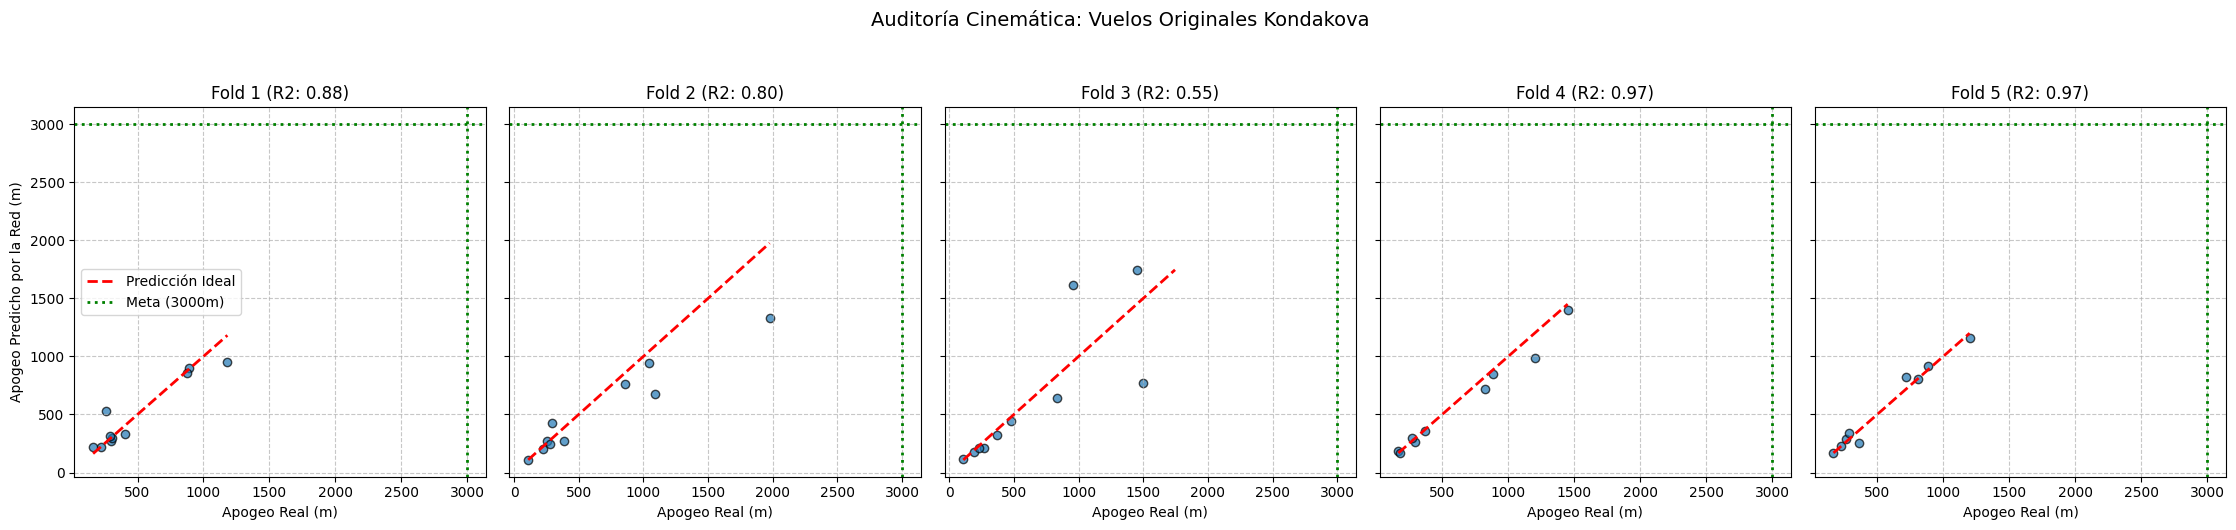

In [48]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS ORIGINALES (CON RECONSTRUCCIÓN FÍSICA Y TRIGGER GLOBAL)
# ==============================================================================
# Ajusta esta ruta a tu carpeta con los 48 archivos CSV originales
PROCESSED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/20Hz")
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_originales)}")

# Ventana de 10 segundos (201 muestras a 20Hz) para capturar el MECO
WINDOW_SIZE = 121 
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_originales:
    # 1.1 Leer archivo y limpiar espacios invisibles en los encabezados
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.strip()
    df = df.sort_values("time").reset_index(drop=True)
    
    # 1.2 Reconstruir las características que la IMU no guardó directamente
    if 'At' not in df.columns:
        # Aceleración Total (Magnitud del vector 3D)
        df['At'] = np.sqrt(df['accl_x']**2 + df['accl_y']**2 + df['accl_z']**2)
        
    if 'P' not in df.columns:
        # Reconstruir Presión Atmosférica (Pa) a partir de la Altitud (m) 
        # usando el modelo de Atmósfera Estándar Internacional (ISA)
        df['P'] = 101325.0 * (1 - 2.25577e-5 * df['baro_altitude'])**5.25588
            
    apogeo_real = df["baro_altitude"].max()
    
    # Filtro de sobre de vuelo (Ignoramos vuelos erráticos de más de 4500m)
    if apogeo_real > 4500:
        continue
    
    # 1.3 DISPARADOR DE DESPEGUE ROBUSTO
    # Usamos At > 15 m/s^2 (aprox 1.5G). Al usar At, no importa cómo orientaron la placa.
    despegues = df[df['At'] > 15].index
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # 1.4 Extraer la ventana exactamente desde el instante del despegue
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.stem) 

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtros físicos: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Usando splits por secuencia en lugar de por vuelo.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN (RobustScaler)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1: axes = [axes]
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        ax.scatter(y_true, y_pred, alpha=0.7, c='#1f77b4', edgecolors='k')
        
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
            ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
            
    plt.suptitle("Auditoría Cinemática: Vuelos Originales Kondakova", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida_Originales")
    model.add(Input(shape=input_shape))
    
    # Reducimos GaussianNoise porque la IMU real ya tiene suficiente vibración
    model.add(GaussianNoise(0.01)) 
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    
    return model

# ==============================================================================
# 5. EJECUCIÓN
# ==============================================================================
print("\nIniciando Evaluación Híbrida con Datos Reales...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=200, 
    batch_size=16, 
    patience=30
)

summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — ARCHIVOS ORIGINALES")
plot_kfold_diagnostics(cv_lstm_v5_folds)

PRUEBA CON 20HZ, WINDOW 201, DENSE 16, DROP 0.4

Archivos localizados: 48
Secuencias extraídas tras filtros físicos: (48, 201, 6)

Iniciando Evaluación Híbrida con Datos Reales...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 69.85 m | R2: 0.9363

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 153.06 m | R2: 0.8104

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 129.30 m | R2: 0.8526

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 70.52 m | R2: 0.9551

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 60.88 m | R2: 0.9255

RESUMEN LSTM Híbrida — ARCHIVOS ORIGINALES (METROS REALES)
MAE  : 96.72 ± 37.22 metros
RMSE : 141.20 metros
R2   : 0.8960


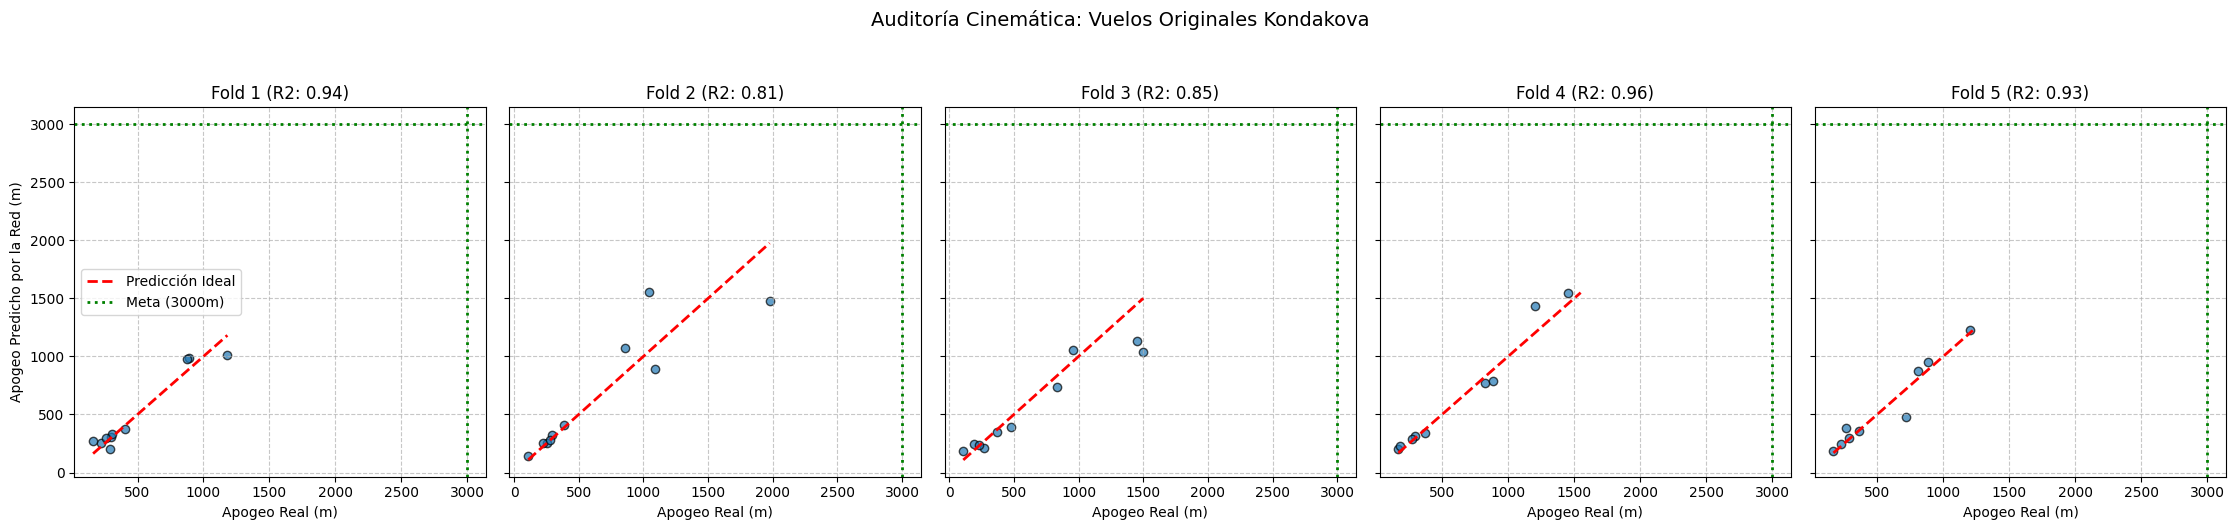

In [54]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS ORIGINALES (CON RECONSTRUCCIÓN FÍSICA Y TRIGGER GLOBAL)
# ==============================================================================
# Ajusta esta ruta a tu carpeta con los 48 archivos CSV originales
PROCESSED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/20Hz")
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_originales)}")

# Ventana de 10 segundos (201 muestras a 20Hz) para capturar el MECO
WINDOW_SIZE = 201 
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_originales:
    # 1.1 Leer archivo y limpiar espacios invisibles en los encabezados
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.strip()
    df = df.sort_values("time").reset_index(drop=True)
    
    # 1.2 Reconstruir las características que la IMU no guardó directamente
    if 'At' not in df.columns:
        # Aceleración Total (Magnitud del vector 3D)
        df['At'] = np.sqrt(df['accl_x']**2 + df['accl_y']**2 + df['accl_z']**2)
        
    if 'P' not in df.columns:
        # Reconstruir Presión Atmosférica (Pa) a partir de la Altitud (m) 
        # usando el modelo de Atmósfera Estándar Internacional (ISA)
        df['P'] = 101325.0 * (1 - 2.25577e-5 * df['baro_altitude'])**5.25588
            
    apogeo_real = df["baro_altitude"].max()
    
    # Filtro de sobre de vuelo (Ignoramos vuelos erráticos de más de 4500m)
    if apogeo_real > 4500:
        continue
    
    # 1.3 DISPARADOR DE DESPEGUE ROBUSTO
    # Usamos At > 15 m/s^2 (aprox 1.5G). Al usar At, no importa cómo orientaron la placa.
    despegues = df[df['At'] > 15].index
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # 1.4 Extraer la ventana exactamente desde el instante del despegue
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.stem) 

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtros físicos: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Usando splits por secuencia en lugar de por vuelo.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN (RobustScaler)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1: axes = [axes]
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        ax.scatter(y_true, y_pred, alpha=0.7, c='#1f77b4', edgecolors='k')
        
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
            ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
            
    plt.suptitle("Auditoría Cinemática: Vuelos Originales Kondakova", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida_Originales")
    model.add(Input(shape=input_shape))
    
    # Reducimos GaussianNoise porque la IMU real ya tiene suficiente vibración
    model.add(GaussianNoise(0.01)) 
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    
    model.add(BatchNormalization())
    model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.4))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    
    return model

# ==============================================================================
# 5. EJECUCIÓN
# ==============================================================================
print("\nIniciando Evaluación Híbrida con Datos Reales...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=200, 
    batch_size=16, 
    patience=30
)

summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — ARCHIVOS ORIGINALES")
plot_kfold_diagnostics(cv_lstm_v5_folds)

PRUEBA CON 20HZ, WINDOW 201, DENSE 32, DROP 0.4

Archivos localizados: 48
Secuencias extraídas tras filtros físicos: (48, 201, 6)

Iniciando Evaluación Híbrida con Datos Reales...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 63.94 m | R2: 0.9352

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 174.88 m | R2: 0.5439

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 95.34 m | R2: 0.8942

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 72.45 m | R2: 0.9423

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 73.60 m | R2: 0.8987

RESUMEN LSTM Híbrida — ARCHIVOS ORIGINALES (METROS REALES)
MAE  : 96.04 ± 40.76 metros
RMSE : 168.02 metros
R2   : 0.8428


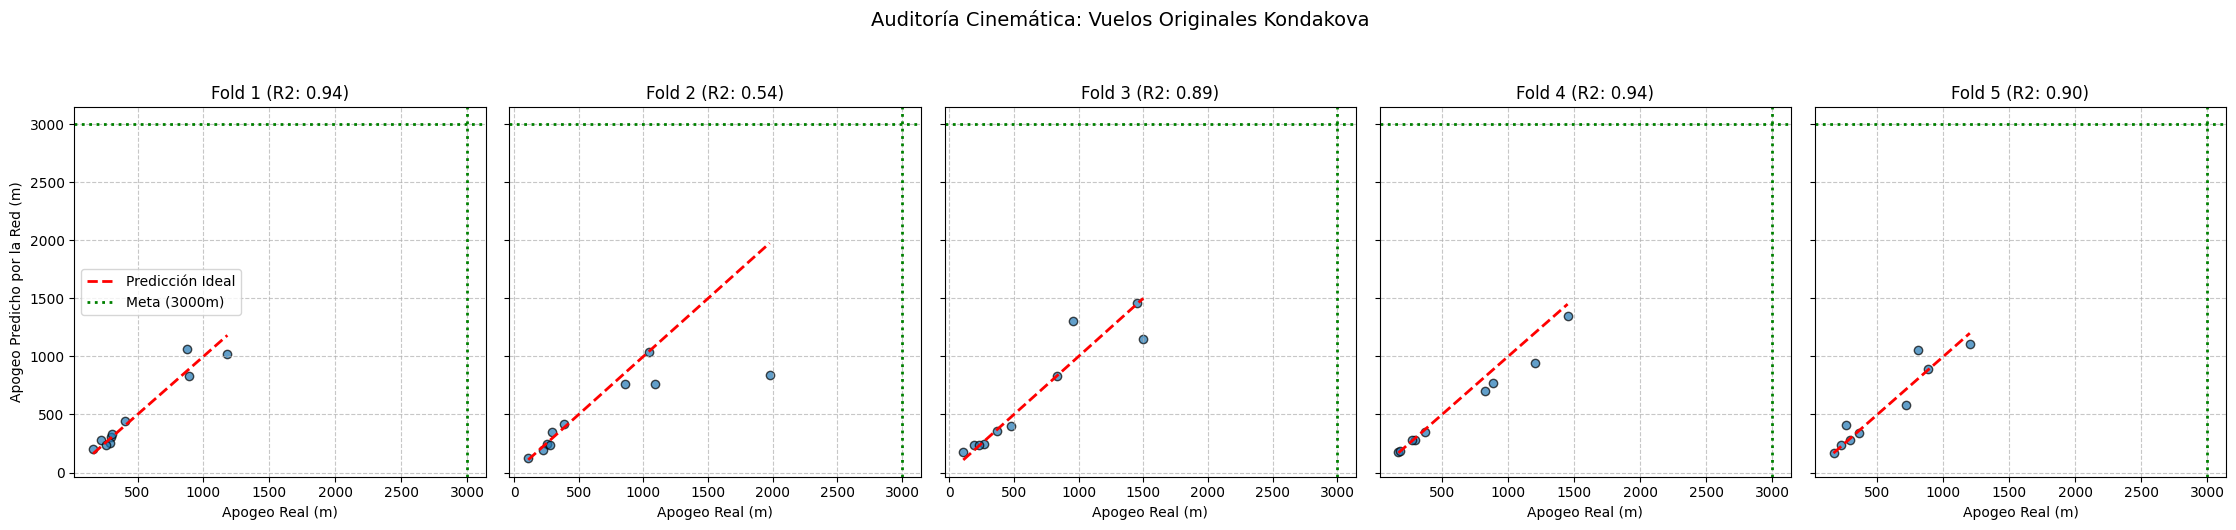

In [55]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS ORIGINALES (CON RECONSTRUCCIÓN FÍSICA Y TRIGGER GLOBAL)
# ==============================================================================
# Ajusta esta ruta a tu carpeta con los 48 archivos CSV originales
PROCESSED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/20Hz")
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_originales)}")

# Ventana de 10 segundos (201 muestras a 20Hz) para capturar el MECO
WINDOW_SIZE = 201 
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_originales:
    # 1.1 Leer archivo y limpiar espacios invisibles en los encabezados
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.strip()
    df = df.sort_values("time").reset_index(drop=True)
    
    # 1.2 Reconstruir las características que la IMU no guardó directamente
    if 'At' not in df.columns:
        # Aceleración Total (Magnitud del vector 3D)
        df['At'] = np.sqrt(df['accl_x']**2 + df['accl_y']**2 + df['accl_z']**2)
        
    if 'P' not in df.columns:
        # Reconstruir Presión Atmosférica (Pa) a partir de la Altitud (m) 
        # usando el modelo de Atmósfera Estándar Internacional (ISA)
        df['P'] = 101325.0 * (1 - 2.25577e-5 * df['baro_altitude'])**5.25588
            
    apogeo_real = df["baro_altitude"].max()
    
    # Filtro de sobre de vuelo (Ignoramos vuelos erráticos de más de 4500m)
    if apogeo_real > 4500:
        continue
    
    # 1.3 DISPARADOR DE DESPEGUE ROBUSTO
    # Usamos At > 15 m/s^2 (aprox 1.5G). Al usar At, no importa cómo orientaron la placa.
    despegues = df[df['At'] > 15].index
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # 1.4 Extraer la ventana exactamente desde el instante del despegue
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.stem) 

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtros físicos: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Usando splits por secuencia en lugar de por vuelo.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN (RobustScaler)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1: axes = [axes]
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        ax.scatter(y_true, y_pred, alpha=0.7, c='#1f77b4', edgecolors='k')
        
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
            ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
            
    plt.suptitle("Auditoría Cinemática: Vuelos Originales Kondakova", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida_Originales")
    model.add(Input(shape=input_shape))
    
    # Reducimos GaussianNoise porque la IMU real ya tiene suficiente vibración
    model.add(GaussianNoise(0.01)) 
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    
    model.add(BatchNormalization())
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.4))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    
    return model

# ==============================================================================
# 5. EJECUCIÓN
# ==============================================================================
print("\nIniciando Evaluación Híbrida con Datos Reales...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=200, 
    batch_size=16, 
    patience=30
)

summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — ARCHIVOS ORIGINALES")
plot_kfold_diagnostics(cv_lstm_v5_folds)

PRUEBA CON 20HZ, WINDOW 201, DENSE 64, DROP 0.4

Archivos localizados: 48
Secuencias extraídas tras filtros físicos: (48, 201, 6)

Iniciando Evaluación Híbrida con Datos Reales...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 31.92 m | R2: 0.9847

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 138.70 m | R2: 0.6659

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 64.36 m | R2: 0.9438

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 44.37 m | R2: 0.9860

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 31.89 m | R2: 0.9838

RESUMEN LSTM Híbrida — ARCHIVOS ORIGINALES (METROS REALES)
MAE  : 62.25 ± 40.03 metros
RMSE : 115.57 metros
R2   : 0.9128


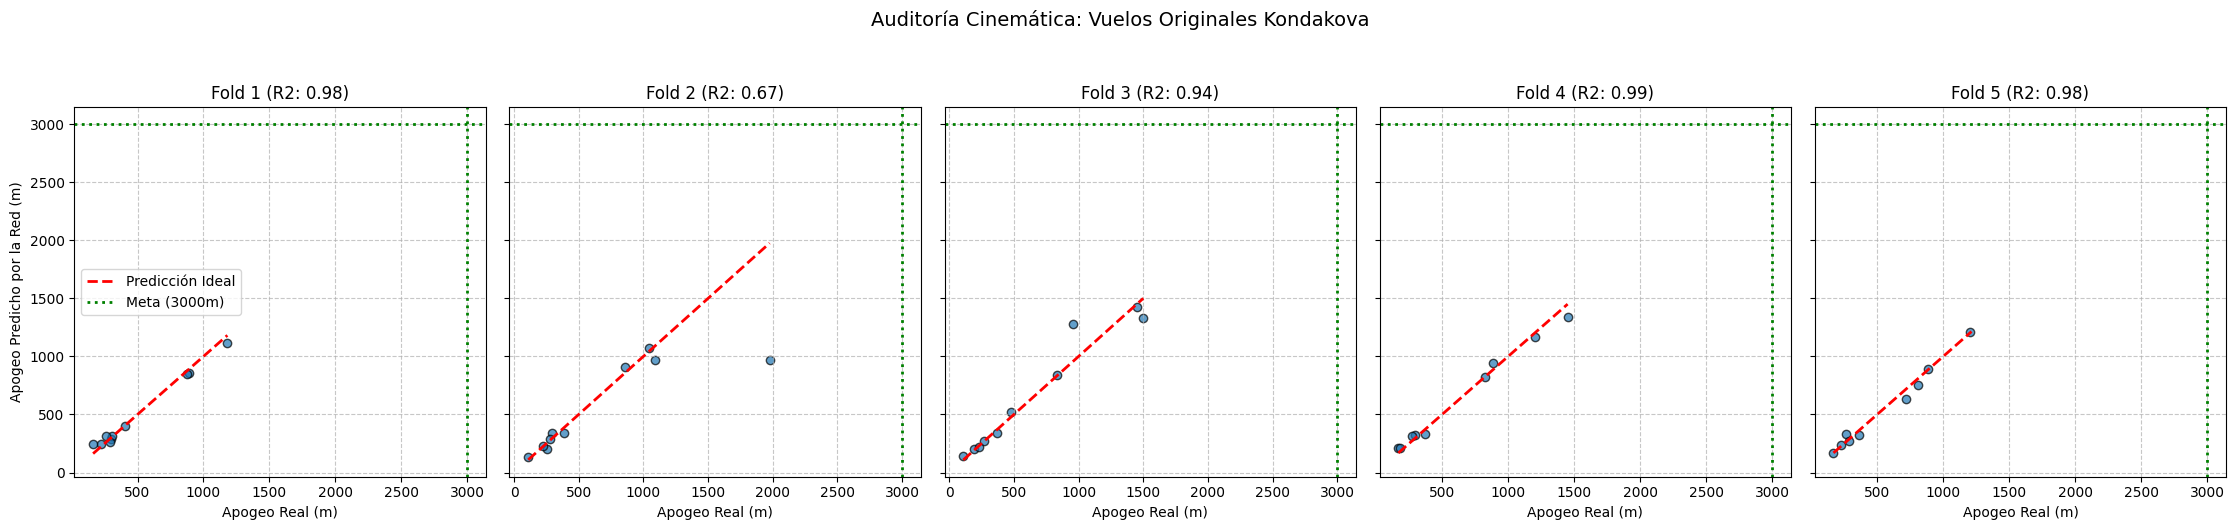

In [56]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS ORIGINALES (CON RECONSTRUCCIÓN FÍSICA Y TRIGGER GLOBAL)
# ==============================================================================
# Ajusta esta ruta a tu carpeta con los 48 archivos CSV originales
PROCESSED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/20Hz")
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_originales)}")

# Ventana de 10 segundos (201 muestras a 20Hz) para capturar el MECO
WINDOW_SIZE = 201 
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_originales:
    # 1.1 Leer archivo y limpiar espacios invisibles en los encabezados
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.strip()
    df = df.sort_values("time").reset_index(drop=True)
    
    # 1.2 Reconstruir las características que la IMU no guardó directamente
    if 'At' not in df.columns:
        # Aceleración Total (Magnitud del vector 3D)
        df['At'] = np.sqrt(df['accl_x']**2 + df['accl_y']**2 + df['accl_z']**2)
        
    if 'P' not in df.columns:
        # Reconstruir Presión Atmosférica (Pa) a partir de la Altitud (m) 
        # usando el modelo de Atmósfera Estándar Internacional (ISA)
        df['P'] = 101325.0 * (1 - 2.25577e-5 * df['baro_altitude'])**5.25588
            
    apogeo_real = df["baro_altitude"].max()
    
    # Filtro de sobre de vuelo (Ignoramos vuelos erráticos de más de 4500m)
    if apogeo_real > 4500:
        continue
    
    # 1.3 DISPARADOR DE DESPEGUE ROBUSTO
    # Usamos At > 15 m/s^2 (aprox 1.5G). Al usar At, no importa cómo orientaron la placa.
    despegues = df[df['At'] > 15].index
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # 1.4 Extraer la ventana exactamente desde el instante del despegue
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.stem) 

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtros físicos: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Usando splits por secuencia en lugar de por vuelo.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN (RobustScaler)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1: axes = [axes]
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        ax.scatter(y_true, y_pred, alpha=0.7, c='#1f77b4', edgecolors='k')
        
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
            ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
            
    plt.suptitle("Auditoría Cinemática: Vuelos Originales Kondakova", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida_Originales")
    model.add(Input(shape=input_shape))
    
    # Reducimos GaussianNoise porque la IMU real ya tiene suficiente vibración
    model.add(GaussianNoise(0.01)) 
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.4))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    
    return model

# ==============================================================================
# 5. EJECUCIÓN
# ==============================================================================
print("\nIniciando Evaluación Híbrida con Datos Reales...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=200, 
    batch_size=16, 
    patience=30
)

summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — ARCHIVOS ORIGINALES")
plot_kfold_diagnostics(cv_lstm_v5_folds)

PRUEBA CON 20HZ, WINDOW 201, DENSE 16, DROP 0.2

Archivos localizados: 48
Secuencias extraídas tras filtros físicos: (48, 201, 6)

Iniciando Evaluación Híbrida con Datos Reales...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 42.50 m | R2: 0.9699

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 210.03 m | R2: 0.6647

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 126.71 m | R2: 0.8763

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 69.95 m | R2: 0.9538

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 66.78 m | R2: 0.9197

RESUMEN LSTM Híbrida — ARCHIVOS ORIGINALES (METROS REALES)
MAE  : 103.20 ± 60.14 metros
RMSE : 149.73 metros
R2   : 0.8769


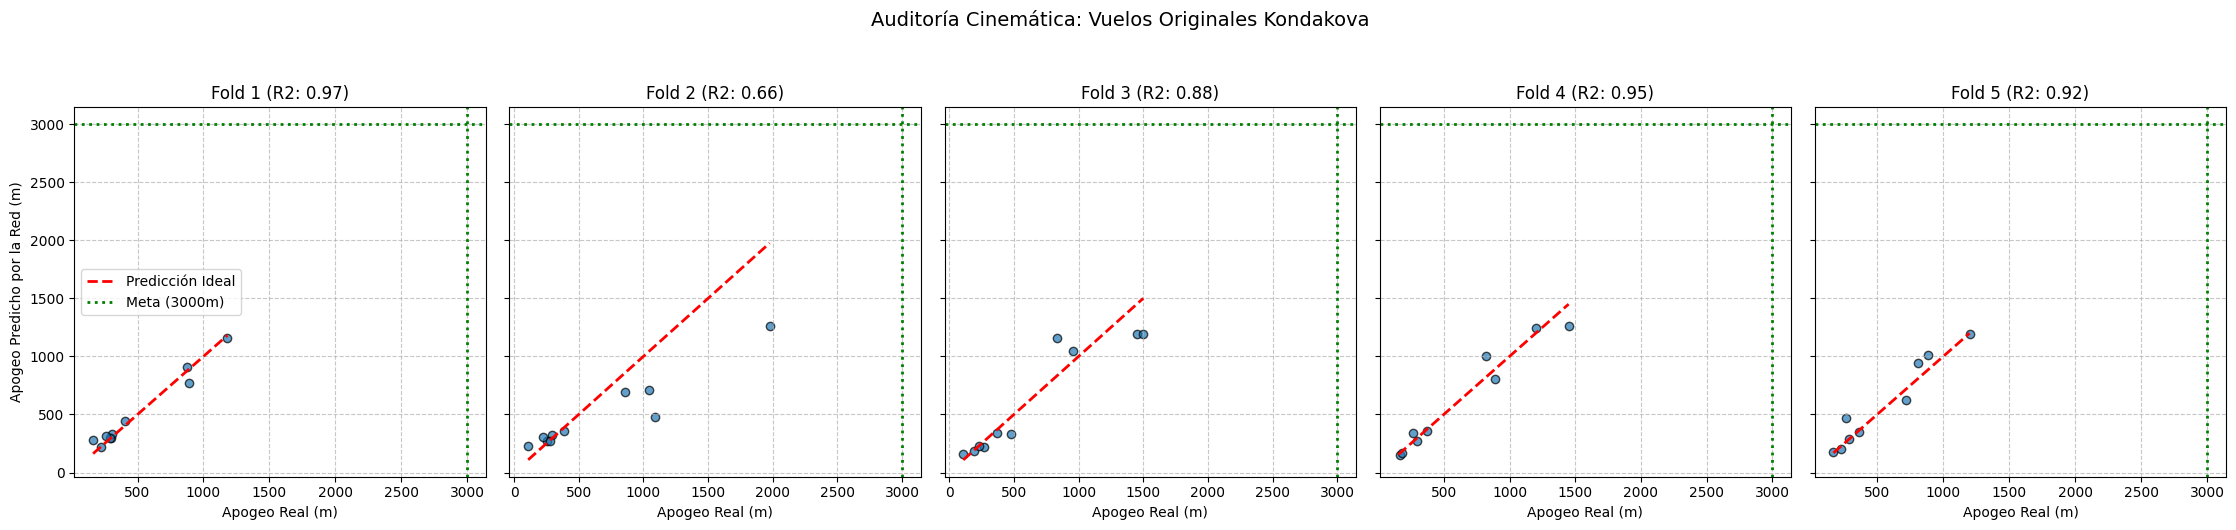

In [57]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS ORIGINALES (CON RECONSTRUCCIÓN FÍSICA Y TRIGGER GLOBAL)
# ==============================================================================
# Ajusta esta ruta a tu carpeta con los 48 archivos CSV originales
PROCESSED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/20Hz")
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_originales)}")

# Ventana de 10 segundos (201 muestras a 20Hz) para capturar el MECO
WINDOW_SIZE = 201 
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_originales:
    # 1.1 Leer archivo y limpiar espacios invisibles en los encabezados
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.strip()
    df = df.sort_values("time").reset_index(drop=True)
    
    # 1.2 Reconstruir las características que la IMU no guardó directamente
    if 'At' not in df.columns:
        # Aceleración Total (Magnitud del vector 3D)
        df['At'] = np.sqrt(df['accl_x']**2 + df['accl_y']**2 + df['accl_z']**2)
        
    if 'P' not in df.columns:
        # Reconstruir Presión Atmosférica (Pa) a partir de la Altitud (m) 
        # usando el modelo de Atmósfera Estándar Internacional (ISA)
        df['P'] = 101325.0 * (1 - 2.25577e-5 * df['baro_altitude'])**5.25588
            
    apogeo_real = df["baro_altitude"].max()
    
    # Filtro de sobre de vuelo (Ignoramos vuelos erráticos de más de 4500m)
    if apogeo_real > 4500:
        continue
    
    # 1.3 DISPARADOR DE DESPEGUE ROBUSTO
    # Usamos At > 15 m/s^2 (aprox 1.5G). Al usar At, no importa cómo orientaron la placa.
    despegues = df[df['At'] > 15].index
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # 1.4 Extraer la ventana exactamente desde el instante del despegue
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.stem) 

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtros físicos: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Usando splits por secuencia en lugar de por vuelo.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN (RobustScaler)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1: axes = [axes]
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        ax.scatter(y_true, y_pred, alpha=0.7, c='#1f77b4', edgecolors='k')
        
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
            ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
            
    plt.suptitle("Auditoría Cinemática: Vuelos Originales Kondakova", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida_Originales")
    model.add(Input(shape=input_shape))
    
    # Reducimos GaussianNoise porque la IMU real ya tiene suficiente vibración
    model.add(GaussianNoise(0.01)) 
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    
    model.add(BatchNormalization())
    model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    
    return model

# ==============================================================================
# 5. EJECUCIÓN
# ==============================================================================
print("\nIniciando Evaluación Híbrida con Datos Reales...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=200, 
    batch_size=16, 
    patience=30
)

summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — ARCHIVOS ORIGINALES")
plot_kfold_diagnostics(cv_lstm_v5_folds)

PRUEBA CON 20HZ, WINDOW 201, DENSE 32, DROP 0.2

Archivos localizados: 48
Secuencias extraídas tras filtros físicos: (48, 201, 6)

Iniciando Evaluación Híbrida con Datos Reales...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 64.25 m | R2: 0.9381

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 162.17 m | R2: 0.8548

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 146.49 m | R2: 0.7777

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 59.59 m | R2: 0.9707

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 109.16 m | R2: 0.8381

RESUMEN LSTM Híbrida — ARCHIVOS ORIGINALES (METROS REALES)
MAE  : 108.34 ± 41.65 metros
RMSE : 148.73 metros
R2   : 0.8759


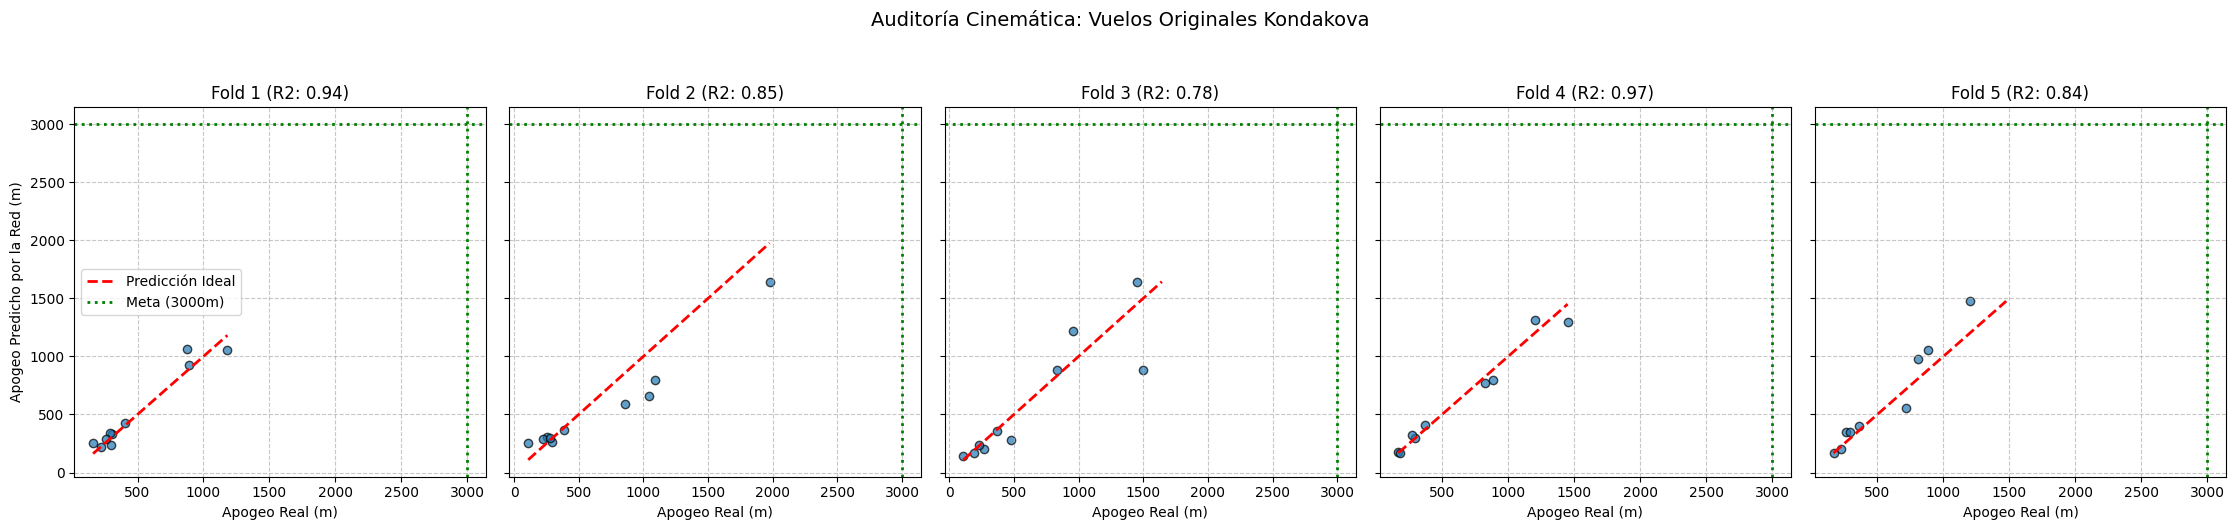

In [58]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS ORIGINALES (CON RECONSTRUCCIÓN FÍSICA Y TRIGGER GLOBAL)
# ==============================================================================
# Ajusta esta ruta a tu carpeta con los 48 archivos CSV originales
PROCESSED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/20Hz")
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_originales)}")

# Ventana de 10 segundos (201 muestras a 20Hz) para capturar el MECO
WINDOW_SIZE = 201 
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_originales:
    # 1.1 Leer archivo y limpiar espacios invisibles en los encabezados
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.strip()
    df = df.sort_values("time").reset_index(drop=True)
    
    # 1.2 Reconstruir las características que la IMU no guardó directamente
    if 'At' not in df.columns:
        # Aceleración Total (Magnitud del vector 3D)
        df['At'] = np.sqrt(df['accl_x']**2 + df['accl_y']**2 + df['accl_z']**2)
        
    if 'P' not in df.columns:
        # Reconstruir Presión Atmosférica (Pa) a partir de la Altitud (m) 
        # usando el modelo de Atmósfera Estándar Internacional (ISA)
        df['P'] = 101325.0 * (1 - 2.25577e-5 * df['baro_altitude'])**5.25588
            
    apogeo_real = df["baro_altitude"].max()
    
    # Filtro de sobre de vuelo (Ignoramos vuelos erráticos de más de 4500m)
    if apogeo_real > 4500:
        continue
    
    # 1.3 DISPARADOR DE DESPEGUE ROBUSTO
    # Usamos At > 15 m/s^2 (aprox 1.5G). Al usar At, no importa cómo orientaron la placa.
    despegues = df[df['At'] > 15].index
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # 1.4 Extraer la ventana exactamente desde el instante del despegue
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.stem) 

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtros físicos: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Usando splits por secuencia en lugar de por vuelo.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN (RobustScaler)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1: axes = [axes]
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        ax.scatter(y_true, y_pred, alpha=0.7, c='#1f77b4', edgecolors='k')
        
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
            ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
            
    plt.suptitle("Auditoría Cinemática: Vuelos Originales Kondakova", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida_Originales")
    model.add(Input(shape=input_shape))
    
    # Reducimos GaussianNoise porque la IMU real ya tiene suficiente vibración
    model.add(GaussianNoise(0.01)) 
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    
    model.add(BatchNormalization())
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    
    return model

# ==============================================================================
# 5. EJECUCIÓN
# ==============================================================================
print("\nIniciando Evaluación Híbrida con Datos Reales...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=200, 
    batch_size=16, 
    patience=30
)

summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — ARCHIVOS ORIGINALES")
plot_kfold_diagnostics(cv_lstm_v5_folds)

PRUEBA CON 20HZ, WINDOW 201, DENSE 64, DROP 0.2

Archivos localizados: 48
Secuencias extraídas tras filtros físicos: (48, 201, 6)

Iniciando Evaluación Híbrida con Datos Reales...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 77.92 m | R2: 0.9067

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 166.93 m | R2: 0.7496

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 126.39 m | R2: 0.8503

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 43.47 m | R2: 0.9752

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 34.40 m | R2: 0.9738

RESUMEN LSTM Híbrida — ARCHIVOS ORIGINALES (METROS REALES)
MAE  : 89.82 ± 50.29 metros
RMSE : 139.76 metros
R2   : 0.8911


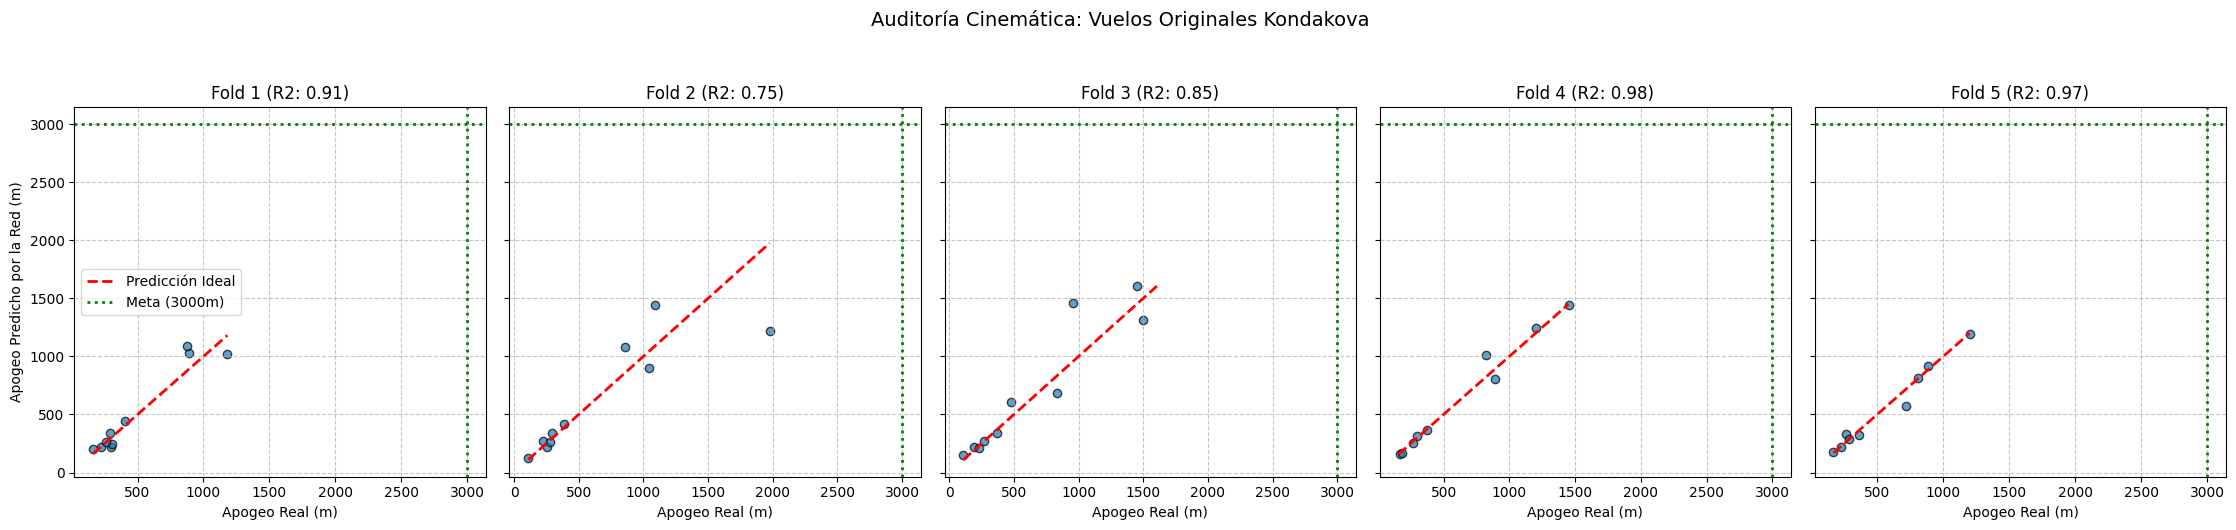

In [59]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS ORIGINALES (CON RECONSTRUCCIÓN FÍSICA Y TRIGGER GLOBAL)
# ==============================================================================
# Ajusta esta ruta a tu carpeta con los 48 archivos CSV originales
PROCESSED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/20Hz")
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_originales)}")

# Ventana de 10 segundos (201 muestras a 20Hz) para capturar el MECO
WINDOW_SIZE = 201 
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_originales:
    # 1.1 Leer archivo y limpiar espacios invisibles en los encabezados
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.strip()
    df = df.sort_values("time").reset_index(drop=True)
    
    # 1.2 Reconstruir las características que la IMU no guardó directamente
    if 'At' not in df.columns:
        # Aceleración Total (Magnitud del vector 3D)
        df['At'] = np.sqrt(df['accl_x']**2 + df['accl_y']**2 + df['accl_z']**2)
        
    if 'P' not in df.columns:
        # Reconstruir Presión Atmosférica (Pa) a partir de la Altitud (m) 
        # usando el modelo de Atmósfera Estándar Internacional (ISA)
        df['P'] = 101325.0 * (1 - 2.25577e-5 * df['baro_altitude'])**5.25588
            
    apogeo_real = df["baro_altitude"].max()
    
    # Filtro de sobre de vuelo (Ignoramos vuelos erráticos de más de 4500m)
    if apogeo_real > 4500:
        continue
    
    # 1.3 DISPARADOR DE DESPEGUE ROBUSTO
    # Usamos At > 15 m/s^2 (aprox 1.5G). Al usar At, no importa cómo orientaron la placa.
    despegues = df[df['At'] > 15].index
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # 1.4 Extraer la ventana exactamente desde el instante del despegue
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.stem) 

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtros físicos: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Usando splits por secuencia en lugar de por vuelo.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN (RobustScaler)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1: axes = [axes]
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        ax.scatter(y_true, y_pred, alpha=0.7, c='#1f77b4', edgecolors='k')
        
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
            ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
            
    plt.suptitle("Auditoría Cinemática: Vuelos Originales Kondakova", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida_Originales")
    model.add(Input(shape=input_shape))
    
    # Reducimos GaussianNoise porque la IMU real ya tiene suficiente vibración
    model.add(GaussianNoise(0.01)) 
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    
    return model

# ==============================================================================
# 5. EJECUCIÓN
# ==============================================================================
print("\nIniciando Evaluación Híbrida con Datos Reales...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=200, 
    batch_size=16, 
    patience=30
)

summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — ARCHIVOS ORIGINALES")
plot_kfold_diagnostics(cv_lstm_v5_folds)

COMPARATTIVA COMBINACIONES

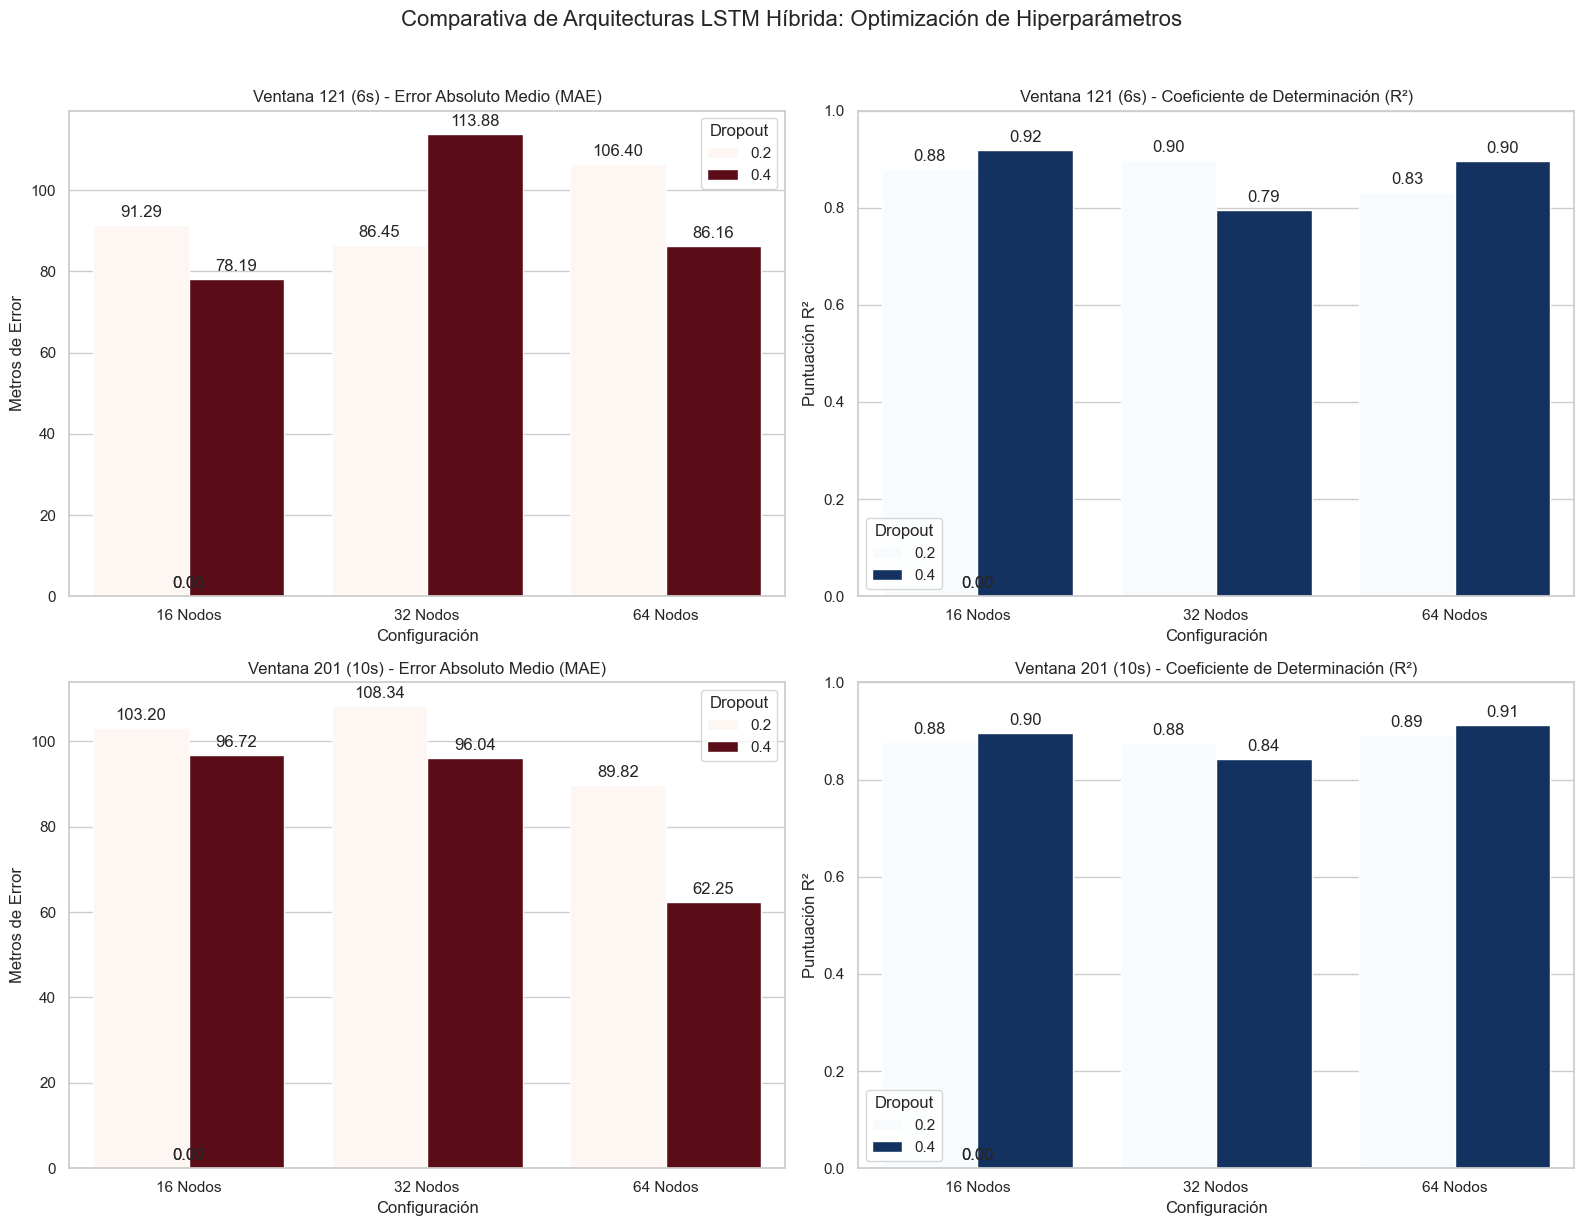

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Vacia aquí los promedios de tus corridas K-Fold. 
# Reemplaza los ceros (0.0) con tus resultados reales de MAE y R2.
datos_experimentos = [
    # Window, Dense, Dropout, MAE, R2
    [121, 16, 0.2, 91.29, 0.8789], 
    [121, 16, 0.4, 78.19, 0.9180],
    [121, 32, 0.2, 86.45, 0.8973],
    [121, 32, 0.4, 113.88, 0.7947],
    [121, 64, 0.2, 106.40, 0.8326],
    [121, 64, 0.4, 86.16, 0.8963],
    
    [201, 16, 0.2, 103.20, 0.8769],
    [201, 16, 0.4, 96.72, 0.8960],
    [201, 32, 0.2, 108.34, 0.8759],
    [201, 32, 0.4, 96.04, 0.8428],
    [201, 64, 0.2, 89.82, 0.8911],
    [201, 64, 0.4, 62.25, 0.9128],
]

df = pd.DataFrame(datos_experimentos, columns=['Window_Size', 'Dense_Units', 'Dropout', 'MAE', 'R2'])
df['Configuración'] = df['Dense_Units'].astype(str) + " Nodos"

# 2. Configurar el lienzo (2 filas: Ventana 121 y 201 | 2 columnas: MAE y R2)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Comparativa de Arquitecturas LSTM Híbrida: Optimización de Hiperparámetros", fontsize=16, y=1.02)

# --- FILA 1: WINDOW SIZE = 121 ---
df_121 = df[df['Window_Size'] == 121]

# Gráfico 1: MAE (Menor es mejor)
sns.barplot(data=df_121, x='Configuración', y='MAE', hue='Dropout', palette="Reds", ax=axes[0, 0])
axes[0, 0].set_title("Ventana 121 (6s) - Error Absoluto Medio (MAE)")
axes[0, 0].set_ylabel("Metros de Error")

# Gráfico 2: R2 (Mayor es mejor)
sns.barplot(data=df_121, x='Configuración', y='R2', hue='Dropout', palette="Blues", ax=axes[0, 1])
axes[0, 1].set_title("Ventana 121 (6s) - Coeficiente de Determinación (R²)")
axes[0, 1].set_ylabel("Puntuación R²")
axes[0, 1].set_ylim(0, 1.0) # El R2 máximo ideal es 1.0

# --- FILA 2: WINDOW SIZE = 201 ---
df_201 = df[df['Window_Size'] == 201]

# Gráfico 3: MAE (Menor es mejor)
sns.barplot(data=df_201, x='Configuración', y='MAE', hue='Dropout', palette="Reds", ax=axes[1, 0])
axes[1, 0].set_title("Ventana 201 (10s) - Error Absoluto Medio (MAE)")
axes[1, 0].set_ylabel("Metros de Error")

# Gráfico 4: R2 (Mayor es mejor)
sns.barplot(data=df_201, x='Configuración', y='R2', hue='Dropout', palette="Blues", ax=axes[1, 1])
axes[1, 1].set_title("Ventana 201 (10s) - Coeficiente de Determinación (R²)")
axes[1, 1].set_ylabel("Puntuación R²")
axes[1, 1].set_ylim(0, 1.0)

# Ajustes visuales finales
for ax in axes.flat:
    ax.legend(title='Dropout')
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')

plt.tight_layout()
plt.show()